<a href="https://colab.research.google.com/github/Upparimanasa-12/ApexPlanet_DataAnalytics_internship/blob/main/EDA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
from google.colab import files
uploaded = files.upload()


Saving raw_dataset.csv to raw_dataset (2).csv


In [7]:
df = pd.read_csv('raw_dataset (2).csv')
# First 5 rows
df.head()

,Customer_ID,Customer_Name,Gender,Date_of_Birth,Transaction_Date,Transaction_Amount,Product_Category,City,Payment_Mode
0,C001,Rahul Sharma,Male,1998-05-12,2024/01/15,1200,Electronics,Bangalore,UPI
1,C002,Anita Verma,Female,2001-11-30,15-01-2024,850,Clothing,Delhi,Credit Card
2,C003,NaN,Female,1995-07-20,2024-01-16,560,Groceries,Mumbai,Debit Card
3,C004,Suresh Kumar,Male,NaN,2024-01-17,2200,Electronics,Chennai,UPI
4,C005,Neha Singh,Female,1999-03-25,2024/01/18,1500,Clothing,NaN,Cash


In [8]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Customer_ID         8 non-null      object
 1   Customer_Name       7 non-null      object
 2   Gender              8 non-null      object
 3   Date_of_Birth       7 non-null      object
 4   Transaction_Date    8 non-null      object
 5   Transaction_Amount  8 non-null      int64 
 6   Product_Category    8 non-null      object
 7   City                6 non-null      object
 8   Payment_Mode        8 non-null      object
dtypes: int64(1), object(8)
memory usage: 708.0+ bytes


In [9]:
# Shape of dataset
df.shape

(8, 9)

In [10]:
df.isnull().sum()

,0
Customer_ID,0
Customer_Name,1
Gender,0
Date_of_Birth,1
Transaction_Date,0
Transaction_Amount,0
Product_Category,0
City,2
Payment_Mode,0


In [21]:
# Fill missing values using forward fill
df.ffill(inplace=True)

In [15]:
df.duplicated().sum()

np.int64(1)

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df.describe()


,Transaction_Amount
count,7.000000
mean,2372.714286
std,3421.200799
min,300.000000
25%,705.000000
50%,1200.000000
75%,1850.000000
max,9999.000000


In [19]:
df.select_dtypes(include='object').describe()


,Customer_ID,Customer_Name,Gender,Date_of_Birth,Transaction_Date,Product_Category,City,Payment_Mode
count,7,7,7,7,7,7,7,7
unique,7,6,2,6,7,4,6,5
top,C001,Anita Verma,Female,1995-07-20,2024/01/15,Electronics,Chennai,UPI
freq,1,2,4,2,1,2,2,3


In [22]:
# Frequency count of Product_Category
df['Product_Category'].value_counts()

,count
Product_Category,
Electronics,2
Clothing,2
Groceries,2
Furniture,1


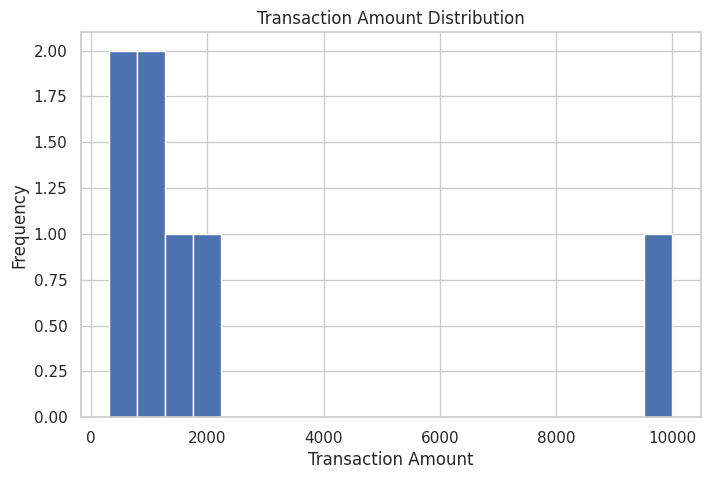

In [25]:
df['Transaction_Amount'].hist(bins=20)
plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

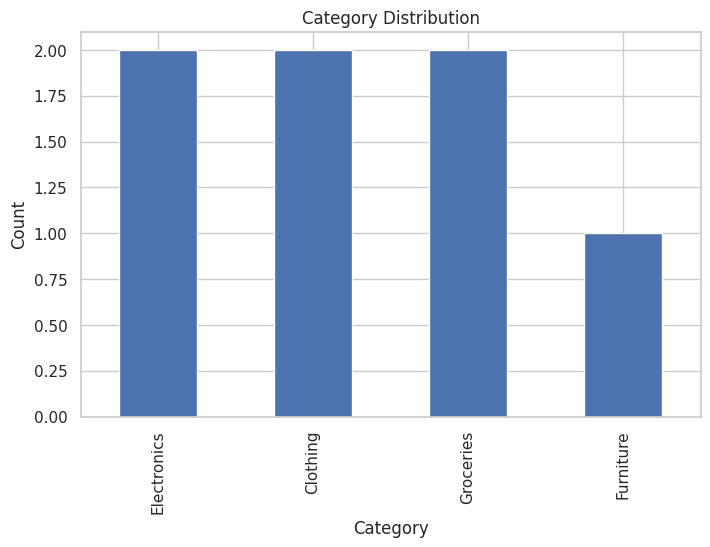

In [28]:
df['Product_Category'].value_counts().plot(kind='bar')
plt.title('Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

In [30]:
# Create revenue column using Transaction_Amount
df['revenue'] = df['Transaction_Amount']

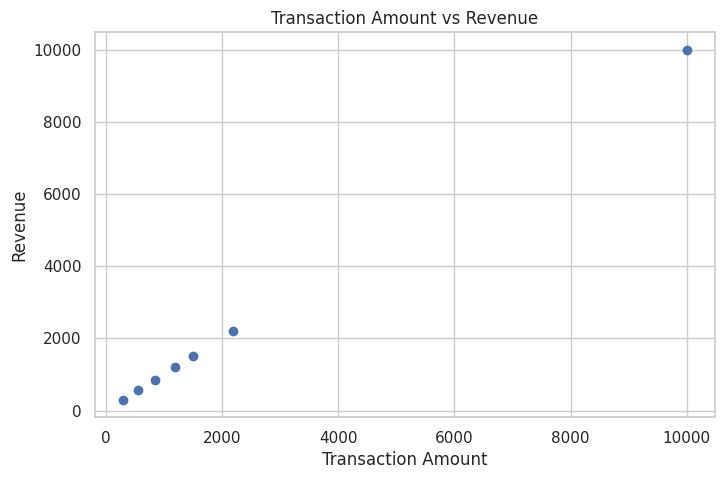

In [32]:
plt.scatter(df['Transaction_Amount'], df['revenue'])
plt.xlabel('Transaction Amount')
plt.ylabel('Revenue')
plt.title('Transaction Amount vs Revenue')
plt.show()

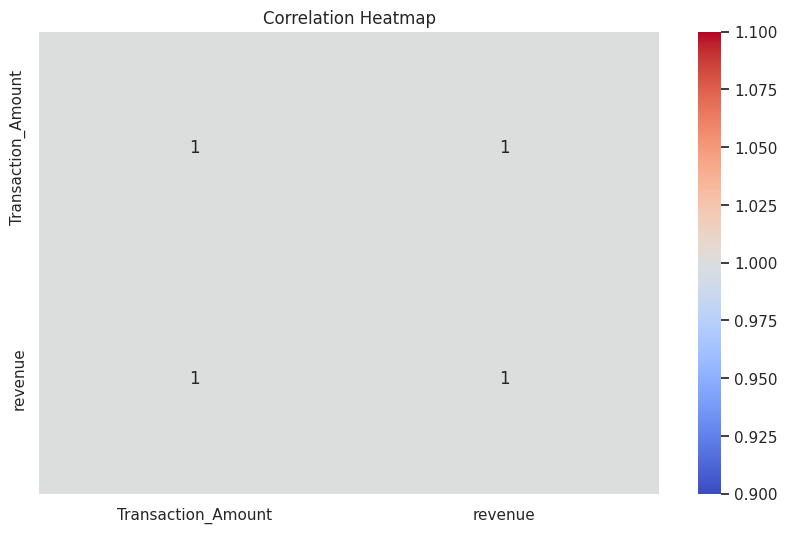

In [34]:
plt.figure(figsize=(10, 6))
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

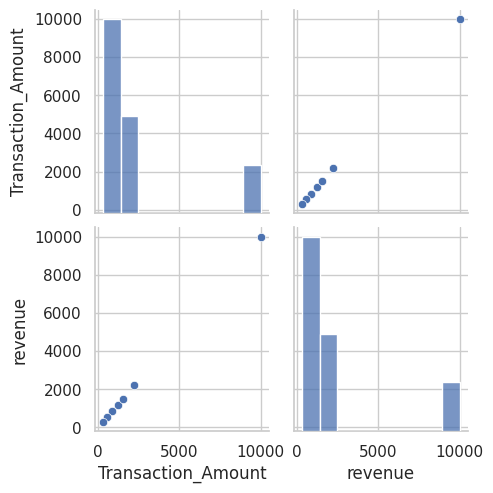

In [36]:
sns.pairplot(df[['Transaction_Amount', 'revenue']])
plt.show()

In [37]:
df.to_csv('cleaned_data.csv', index=False)

In [38]:
files.download('cleaned_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
plt.figure()
df['Transaction_Amount'].hist()
plt.savefig('transaction_amount_distribution.png')
plt.close()

In [42]:
files.download('transaction_amount_distribution.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>